# Cell 0 — Stage 5: Binary Canal Detection (v5 — FICs moved to negative class)

**Pipeline:** Cells 0-6 only. Run in order after kernel restart.

| Cell | Purpose | Time |
|------|---------|------|
| 0 | Header | - |
| 1 | Install smp | ~5s |
| 2 | Config & imports | ~2s |
| 3 | Convert annotations → masks | ~10s |
| 4 | Train model | ~1-2 hrs |
| 5 | Full-mosaic inference | ~30 min |
| 6 | Patch-level visualization | ~5 min |

**Data:** 300 annotated patches in `annotation_v2/`
- 19 canal → mask=1 (POSITIVE)
- 95 FIC + 207 "not canal" + 74 empty → mask=0 (NEGATIVE)

**Key fix from v4:** FICs were incorrectly treated as positive (5x more than canals). Now FICs are negative.

In [2]:
# Cell 1 — Install segmentation_models_pytorch
import subprocess, sys
try:
    import segmentation_models_pytorch as smp
    print(f'smp {smp.__version__} already installed')
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'segmentation-models-pytorch'])
    import segmentation_models_pytorch as smp
    print(f'smp {smp.__version__} installed')

smp 0.5.0 already installed


In [5]:
# Cell 2 — Config & imports
import os, time, warnings, json, glob as globmod
warnings.filterwarnings('ignore')

import numpy as np
import rasterio
from rasterio.windows import Window
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, RandomSampler, WeightedRandomSampler
import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp
import random
import matplotlib.pyplot as plt

DATA_DIR    = r'c:/Users/PRABHAKAR/Documents/Wells-Lab'
OUT_DIR     = os.path.join(DATA_DIR, 'outputs', '05b_binary')
os.makedirs(OUT_DIR, exist_ok=True)

PATCH_SIZE  = 512
BATCH_SIZE  = 4
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

TRAIN_FILES = {
    'ATTANUR_2': (os.path.join(DATA_DIR,'TLBC_D95_ATTANUR_2_ortho.tif'), 0.0462),
    'ATTANUR_3': (os.path.join(DATA_DIR,'TLBC_D95_ATTANUR_3_ortho.tif'), 0.0462),
    'ATTANUR_4': (os.path.join(DATA_DIR,'TLBC_D95_ATTANUR_4_ortho.tif'), 0.0352),
}
VAL_FILES = {
    'ATTANUR_1': (os.path.join(DATA_DIR,'TLBC_D95_ATTANUR_1_ortho.tif'), 0.0462),
}
TEST_FILES = {
    'SHAKAPUR':  (os.path.join(DATA_DIR,'TLBC_D95_SHAKAPUR_ortho.tif'),  0.0342),
}

IMG_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMG_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

print(f'Device: {DEVICE}')
print(f'Task  : Binary canal segmentation (canal=1, background=0)')

Device: cuda
Task  : Binary canal segmentation (canal=1, background=0)


In [6]:
# Cell 3 — Convert annotation_v2 LabelMe JSON → binary masks
# SAFE: reads annotation_v2/ — NEVER deletes it
# "canal" / "distributary" → mask=1 (canal — the WIDE concrete channels)
# "fic" → mask=0 (negative — FICs are NOT canals for blockage detection)
# "not canal" → mask=0 (explicit negative)
# empty annotations → mask=0 (negative)

ANNO_V2 = os.path.join(DATA_DIR, 'annotation_v2')
MASK_V2 = os.path.join(ANNO_V2, 'masks')
os.makedirs(MASK_V2, exist_ok=True)

CANAL_LABELS = {'canal', 'channel', 'distributary', 'minor'}
NEGATIVE_LABELS = {'not canal', 'not_canal', 'notcanal', 'background', 'house',
                   'road', 'pond', 'field', 'fic', 'bund'}
print(f'Labels treated as CANAL (positive): {CANAL_LABELS}')
print(f'Labels treated as NOT CANAL (negative): {NEGATIVE_LABELS}\n')

json_files = sorted(globmod.glob(os.path.join(ANNO_V2, '*.json')))
print(f'Found {len(json_files)} LabelMe JSON files\n')

converted = 0
with_canals = 0
with_fic_only = 0
with_not_canal = 0
empty_masks = 0
all_labels_found = set()
label_counts = {}

for jf in json_files:
    with open(jf) as f:
        anno = json.load(f)

    h = anno['imageHeight']
    w = anno['imageWidth']
    mask = np.zeros((h, w), dtype=np.uint8)
    has_canal = False
    has_fic = False
    has_not_canal = False

    for shape in anno.get('shapes', []):
        lbl = shape['label'].lower().strip()
        all_labels_found.add(lbl)
        label_counts[lbl] = label_counts.get(lbl, 0) + 1

        if lbl in CANAL_LABELS:
            pts = np.array(shape['points'], dtype=np.int32)
            if shape['shape_type'] == 'polygon':
                cv2.fillPoly(mask, [pts], 1)
            elif shape['shape_type'] == 'rectangle':
                cv2.rectangle(mask, tuple(pts[0]), tuple(pts[1]), 1, -1)
            elif shape['shape_type'] == 'line':
                cv2.polylines(mask, [pts], False, 1, thickness=5)
            has_canal = True
        elif lbl == 'fic':
            has_fic = True
        elif lbl in NEGATIVE_LABELS:
            has_not_canal = True

    basename = os.path.splitext(os.path.basename(jf))[0]
    cv2.imwrite(os.path.join(MASK_V2, f'{basename}_mask.png'), mask * 255)
    converted += 1

    if has_canal:
        with_canals += 1
    elif has_fic:
        with_fic_only += 1
    elif has_not_canal:
        with_not_canal += 1
    else:
        empty_masks += 1

print(f'{converted} masks saved to: {MASK_V2}')
print(f'  With canals (positive): {with_canals}')
print(f'  With FIC only (now NEGATIVE): {with_fic_only}')
print(f'  With "not canal" labels (hard negatives): {with_not_canal}')
print(f'  Empty (negatives): {empty_masks}')
print(f'  Total negatives: {with_fic_only + with_not_canal + empty_masks}')
print(f'\nLabel counts: {label_counts}')
print(f'All labels found: {all_labels_found}')

print('\nTraining will use annotation_v2 only for v5.')
print('Old annotation_v1 masks are intentionally excluded to avoid reintroducing FIC-positive labels.')


Labels treated as CANAL (positive): {'channel', 'distributary', 'canal', 'minor'}
Labels treated as NOT CANAL (negative): {'bund', 'background', 'pond', 'not_canal', 'road', 'notcanal', 'house', 'not canal', 'field', 'fic'}

Found 300 LabelMe JSON files

300 masks saved to: c:/Users/PRABHAKAR/Documents/Wells-Lab\annotation_v2\masks
  With canals (positive): 13
  With FIC only (now NEGATIVE): 89
  With "not canal" labels (hard negatives): 124
  Empty (negatives): 74
  Total negatives: 287

Label counts: {'not canal': 207, 'fic': 95, 'canal': 19}
All labels found: {'not canal', 'canal', 'fic'}

Training will use annotation_v2 only for v5.
Old annotation_v1 masks are intentionally excluded to avoid reintroducing FIC-positive labels.


In [9]:
# Cell 4 — Train v5: FICs as negative, 19 canal positives boosted heavily
import gc, shutil
gc.collect()
torch.cuda.empty_cache()

ANNO_V2 = os.path.join(DATA_DIR, 'annotation_v2')
MASK_V2 = os.path.join(ANNO_V2, 'masks')

# ── Collect all annotated pairs ───────────────────────────────────────────────

all_pairs = []
for mf in sorted(globmod.glob(os.path.join(MASK_V2, '*_mask.png'))):
    basename = os.path.basename(mf).replace('_mask.png', '')
    raw_f = os.path.join(ANNO_V2, f'{basename}_raw.npy')
    if os.path.exists(raw_f):
        all_pairs.append((raw_f, mf))

# v5 uses annotation_v2 only. annotation_v1 is excluded because older masks may contain FIC-positive labels.

pos_pairs = [(r, m) for r, m in all_pairs if cv2.imread(m, cv2.IMREAD_GRAYSCALE).max() > 0]
neg_pairs = [(r, m) for r, m in all_pairs if cv2.imread(m, cv2.IMREAD_GRAYSCALE).max() == 0]
print(f'Annotated v5 patches: {len(all_pairs)} ({len(pos_pairs)} positive, {len(neg_pairs)} negative)')
print('  Source: annotation_v2 only')
print('  NOTE: Only canal/channel/distributary/minor are positive. FICs and hard negatives are background.')

# Identify hard negatives: "not canal" AND "fic" labeled patches
HARD_NEG_LABELS = {'not canal', 'not_canal', 'notcanal', 'background', 'house',
                   'road', 'pond', 'field', 'fic', 'bund'}
hard_neg_basenames = set()
fic_neg_basenames = set()
for jf in sorted(globmod.glob(os.path.join(ANNO_V2, '*.json'))):
    with open(jf) as f:
        anno = json.load(f)
    bn = os.path.splitext(os.path.basename(jf))[0]
    for shape in anno.get('shapes', []):
        lbl = shape['label'].lower().strip()
        if lbl in HARD_NEG_LABELS:
            hard_neg_basenames.add(bn)
        if lbl == 'fic':
            fic_neg_basenames.add(bn)

hard_neg_pairs = []
fic_neg_pairs = []
soft_neg_pairs = []
for r, m in neg_pairs:
    basename = os.path.splitext(os.path.basename(r))[0].replace('_raw', '')
    if basename in fic_neg_basenames:
        fic_neg_pairs.append((r, m))
        hard_neg_pairs.append((r, m))
    elif basename in hard_neg_basenames:
        hard_neg_pairs.append((r, m))
    else:
        soft_neg_pairs.append((r, m))

print(f'  Hard negatives ("not canal"): {len(hard_neg_pairs) - len(fic_neg_pairs)}')
print(f'  FIC negatives (now negative!): {len(fic_neg_pairs)}')
print(f'  Soft negatives (empty): {len(soft_neg_pairs)}')

# ── Clear old augmented/pseudo dirs ──────────────────────────────────────────

AUG_DIR = os.path.join(OUT_DIR, 'augmented_positives')
PSEUDO_DIR = os.path.join(OUT_DIR, 'pseudo_labels')
PSEUDO_DIR2 = os.path.join(OUT_DIR, 'pseudo_labels_r2')

for d in [AUG_DIR, PSEUDO_DIR, PSEUDO_DIR2]:
    if os.path.exists(d):
        shutil.rmtree(d)
        print(f'  Cleared {d}')
os.makedirs(AUG_DIR, exist_ok=True)
os.makedirs(PSEUDO_DIR, exist_ok=True)

# ── Offline augmentation: 15x positive patches (more because only 19 positives) ─

print(f'\nGenerating 15 augmented variants per positive patch (only {len(pos_pairs)} positives!) ...')
aug_count = 0
for raw_f, mask_f in pos_pairs:
    img = np.load(raw_f)
    mask = cv2.imread(mask_f, cv2.IMREAD_GRAYSCALE)
    mask = (mask > 127).astype(np.uint8)
    basename = os.path.splitext(os.path.basename(raw_f))[0]

    # 7 geometric variants (4 rot × 2 flip - identity)
    for rot in range(4):
        for flip in range(2):
            if rot == 0 and flip == 0:
                continue
            img_aug = np.rot90(img, rot).copy()
            mask_aug = np.rot90(mask, rot).copy()
            if flip:
                img_aug = np.fliplr(img_aug).copy()
                mask_aug = np.fliplr(mask_aug).copy()
            np.savez_compressed(
                os.path.join(AUG_DIR, f'{basename}_r{rot}f{flip}.npz'),
                img=img_aug, mask=mask_aug
            )
            aug_count += 1

    # 8 more with color jitter
    for j in range(8):
        rot = random.randint(0, 3)
        flip = random.randint(0, 1)
        img_aug = np.rot90(img, rot).copy()
        mask_aug = np.rot90(mask, rot).copy()
        if flip:
            img_aug = np.fliplr(img_aug).copy()
            mask_aug = np.fliplr(mask_aug).copy()
        # Color jitter
        img_f = img_aug.astype(np.float32)
        brightness = random.uniform(0.8, 1.2)
        img_f = np.clip(img_f * brightness, 0, 255)
        noise = np.random.normal(0, 5, img_f.shape).astype(np.float32)
        img_f = np.clip(img_f + noise, 0, 255)
        img_aug = img_f.astype(np.uint8)
        np.savez_compressed(
            os.path.join(AUG_DIR, f'{basename}_jit{j}.npz'),
            img=img_aug, mask=mask_aug
        )
        aug_count += 1

print(f'  Created {aug_count} augmented patches ({len(pos_pairs)} × 15)')

# -- Round-1 pseudo labels --------------------------------------------------

print('\nSkipping old-model pseudo-label bootstrap for v5.')
print('  Reason: v4/v3/v2 models may contain FIC-positive contamination.')
print('  Round 2 will generate pseudo-labels from the newly trained v5 checkpoint instead.')
pseudo_candidates = []
print('  Saved 0 old-model pseudo-label patches')


# ── Loss functions ────────────────────────────────────────────────────────────

class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.85, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_t * focal_weight * bce).mean()

class BoundaryLoss(nn.Module):
    def __init__(self, kernel_size=5):
        super().__init__()
        self.pool = nn.MaxPool2d(kernel_size, stride=1, padding=kernel_size//2)
    def forward(self, logits, targets):
        dilated = self.pool(targets)
        eroded = 1.0 - self.pool(1.0 - targets)
        boundary = (dilated - eroded).clamp(0, 1)
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        weight = 1.0 + 2.0 * boundary
        return (weight * bce).mean()

# ── Dataset ───────────────────────────────────────────────────────────────────

class CanalDatasetV6(Dataset):
    def __init__(self, pairs, aug_dir=None, pseudo_dir=None, augment=False):
        self.entries = []
        for raw_f, mf in pairs:
            self.entries.append(('file', raw_f, mf))
        n_anno = len(self.entries)

        n_aug = 0
        if aug_dir and os.path.exists(aug_dir):
            for af in sorted(globmod.glob(os.path.join(aug_dir, '*.npz'))):
                self.entries.append(('npz', af, None))
                n_aug += 1

        n_pseudo = 0
        if pseudo_dir and os.path.exists(pseudo_dir):
            for pf in sorted(globmod.glob(os.path.join(pseudo_dir, '*.npz'))):
                self.entries.append(('npz', pf, None))
                n_pseudo += 1

        self.augment = augment
        self.n_anno = n_anno
        self.n_aug = n_aug
        self.n_pseudo = n_pseudo

        self.pos_imgs = []
        self.pos_masks = []
        for raw_f, mf in pairs:
            m = cv2.imread(mf, cv2.IMREAD_GRAYSCALE)
            if m.max() > 0:
                self.pos_imgs.append(np.load(raw_f))
                self.pos_masks.append((m > 127).astype(np.uint8))

        print(f'  CanalDatasetV6: {n_anno} annotated + {n_aug} augmented + {n_pseudo} pseudo = {len(self.entries)} total')
        print(f'    ({len(self.pos_imgs)} positive patches for copy-paste)')

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        src_type, path1, path2 = self.entries[idx]
        if src_type == 'file':
            img = np.load(path1)
            mask = cv2.imread(path2, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 127).astype(np.uint8)
        else:
            data = np.load(path1)
            img = data['img']
            mask = data['mask']

        img_t  = torch.from_numpy(img.copy()).permute(2, 0, 1).float() / 255.0
        mask_t = torch.from_numpy(mask.copy()).float()
        img_t  = (img_t - IMG_MEAN) / IMG_STD

        if self.augment:
            # Higher copy-paste rate (50%) since we have so few positives
            if random.random() < 0.5 and len(self.pos_imgs) > 0:
                si = random.randint(0, len(self.pos_imgs) - 1)
                src_t = torch.from_numpy(self.pos_imgs[si].copy()).permute(2,0,1).float() / 255.0
                src_t = (src_t - IMG_MEAN) / IMG_STD
                src_m = torch.from_numpy(self.pos_masks[si].copy()).float()
                k = random.choice([0,1,2,3])
                if k > 0:
                    src_t = torch.rot90(src_t, k, dims=[1,2])
                    src_m = torch.rot90(src_m, k, dims=[0,1])
                if random.random() > 0.5:
                    src_t = TF.hflip(src_t); src_m = TF.hflip(src_m.unsqueeze(0)).squeeze(0)
                pm = src_m > 0.5
                img_t[:, pm] = src_t[:, pm]
                mask_t[pm] = 1.0
            if random.random() > 0.5:
                img_t = TF.hflip(img_t); mask_t = TF.hflip(mask_t.unsqueeze(0)).squeeze(0)
            if random.random() > 0.5:
                img_t = TF.vflip(img_t); mask_t = TF.vflip(mask_t.unsqueeze(0)).squeeze(0)
            k = random.choice([0,1,2,3])
            if k > 0:
                img_t = torch.rot90(img_t, k, dims=[1,2])
                mask_t = torch.rot90(mask_t, k, dims=[0,1])
            if random.random() > 0.5:
                img_t = (img_t * random.uniform(0.8, 1.2)).clamp(-3, 3)
            if random.random() > 0.5:
                img_t = img_t + torch.randn_like(img_t) * 0.03
        return img_t, mask_t.unsqueeze(0)

# ══════════════════════════════════════════════════════════════════════════════
# ROUND 1
# ══════════════════════════════════════════════════════════════════════════════

print('\n' + '='*75)
print('ROUND 1: Training v5 — canals only (FICs are negative)')
print('='*75)

random.seed(42)
random.shuffle(all_pairs)
n_val = max(10, len(all_pairs) // 5)
n_train = len(all_pairs) - n_val
train_pairs = all_pairs[:n_train]
val_pairs = all_pairs[n_train:]

train_ds = CanalDatasetV6(train_pairs, aug_dir=AUG_DIR, pseudo_dir=PSEUDO_DIR, augment=True)
val_ds = CanalDatasetV6(val_pairs, aug_dir=None, pseudo_dir=None, augment=False)

# Weighted sampler — positives 8x (very few!), FIC negatives 3x, hard neg 3x
hard_neg_raws = set(r for r, m in hard_neg_pairs)
fic_neg_raws = set(r for r, m in fic_neg_pairs)
weights = []
for i in range(train_ds.n_anno):
    _, raw_f, mf = train_ds.entries[i]
    m = cv2.imread(mf, cv2.IMREAD_GRAYSCALE)
    if m.max() > 0:
        weights.append(8.0)  # positive canal — very rare, boost heavily
    elif raw_f in fic_neg_raws:
        weights.append(3.0)  # FIC negative — must learn to reject
    elif raw_f in hard_neg_raws:
        weights.append(3.0)  # "not canal" hard negative
    else:
        weights.append(1.0)  # soft negative
for i in range(train_ds.n_aug):
    weights.append(5.0)  # augmented positives — important
for i in range(train_ds.n_pseudo):
    weights.append(2.0)

sampler = WeightedRandomSampler(weights, num_samples=3000, replacement=True)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'\nTrain: {len(train_ds)} total | Val: {len(val_ds)}')
print(f'Weighted 3000 samples/epoch (pos 8x, fic_neg 3x, hard_neg 3x, aug 5x, pseudo 2x, soft 1x)')

model = smp.Unet(encoder_name='resnet34', encoder_weights='imagenet',
                  in_channels=3, classes=1).to(DEVICE)

focal_fn = BinaryFocalLoss(alpha=0.85, gamma=2.0)
dice_fn = smp.losses.DiceLoss(mode='binary', from_logits=True)
boundary_fn = BoundaryLoss(kernel_size=5).to(DEVICE)

def combined_loss(logits, targets):
    return focal_fn(logits, targets) + dice_fn(logits, targets) + 0.5 * boundary_fn(logits, targets)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2, eta_min=1e-6)
scaler = torch.amp.GradScaler('cuda')

EPOCHS = 15
PATIENCE = 2
best_iou = 0.0
wait = 0
best_path = os.path.join(OUT_DIR, 'best_binary_unet_v5.pth')

print(f'Model: UNet-ResNet34 | Loss: Focal(α=0.85) + Dice + 0.5×Boundary')
print(f'Epochs: {EPOCHS} | Patience: {PATIENCE}')
print(f'Saving to: {best_path}')
print('-'*75)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            logits = model(imgs)
            loss = combined_loss(logits, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    all_tp, all_fp, all_fn = 0, 0, 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda'):
                logits = model(imgs)
                loss = combined_loss(logits, masks)
            val_loss += loss.item()
            preds = torch.sigmoid(logits)
            pred_bin = (preds > 0.5).float()
            all_tp += (pred_bin * masks).sum().item()
            all_fp += (pred_bin * (1 - masks)).sum().item()
            all_fn += ((1 - pred_bin) * masks).sum().item()
    val_loss /= max(1, len(val_loader))
    precision = all_tp / (all_tp + all_fp + 1e-6)
    recall = all_tp / (all_tp + all_fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    iou = all_tp / (all_tp + all_fp + all_fn + 1e-6)
    scheduler.step()
    lr_now = optimizer.param_groups[0]['lr']
    dt = time.time() - t0
    marker = ''
    if iou > best_iou:
        best_iou = iou; wait = 0
        torch.save(model.state_dict(), best_path)
        marker = ' ** saved'
    else:
        wait += 1
    print(f'E{epoch:02d}  tL={train_loss:.4f}  vL={val_loss:.4f}  IoU={iou:.3f}  P={precision:.3f}  R={recall:.3f}  F1={f1:.3f}  lr={lr_now:.1e}  {dt:.0f}s{marker}')
    if wait >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\nRound 1 Best IoU: {best_iou:.3f}')
round1_iou = best_iou

# ══════════════════════════════════════════════════════════════════════════════
# ROUND 2: Self-training
# ══════════════════════════════════════════════════════════════════════════════

print('\n' + '='*75)
print('ROUND 2: Self-training — better pseudo-labels from Round 1')
print('='*75)

model.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=True))
model.eval()

os.makedirs(PSEUDO_DIR2, exist_ok=True)

print('Generating improved pseudo-labels ...')
STRIDE_P2 = 1024
pseudo_candidates2 = []
SCAN_FILES = {**TRAIN_FILES, **VAL_FILES, **TEST_FILES}

for tag, (fpath, px_m) in SCAN_FILES.items():
    with rasterio.open(fpath) as src:
        W, H = src.width, src.height
    with rasterio.open(fpath) as src:
        for row_off in range(0, H - PATCH_SIZE, STRIDE_P2):
            for col_off in range(0, W - PATCH_SIZE, STRIDE_P2):
                data = src.read([1,2,3,4], window=Window(col_off, row_off, PATCH_SIZE, PATCH_SIZE))
                valid = data[3] == 255
                if valid.sum() / valid.size < 0.7: continue
                rgb = data[:3].astype(np.float32) / 255.0
                img_t = torch.from_numpy(rgb).float()
                img_t = (img_t - IMG_MEAN) / IMG_STD
                with torch.no_grad():
                    with torch.amp.autocast('cuda'):
                        prob = torch.sigmoid(model(img_t.unsqueeze(0).to(DEVICE))).cpu().numpy()[0,0]
                prob[~valid] = 0
                high_conf = (prob > 0.8) | (prob < 0.2)
                conf_ratio = high_conf[valid].sum() / max(1, valid.sum())
                canal_frac = (prob > 0.8).sum() / max(1, valid.sum())
                if conf_ratio > 0.75 and 0.02 < canal_frac < 0.5:
                    rgb_u8 = data[:3].transpose(1,2,0).astype(np.uint8)
                    mask = (prob > 0.8).astype(np.uint8)
                    pseudo_candidates2.append((rgb_u8, mask, conf_ratio))
    print(f'  {tag}: {len(pseudo_candidates2)} patches')

pseudo_candidates2.sort(key=lambda x: x[2], reverse=True)
for i, (rgb, mask, _) in enumerate(pseudo_candidates2[:200]):
    np.savez_compressed(os.path.join(PSEUDO_DIR2, f'pseudo2_{i:03d}.npz'), img=rgb, mask=mask)
print(f'  Saved {min(200, len(pseudo_candidates2))} improved pseudo-labels')

gc.collect(); torch.cuda.empty_cache()

train_ds2 = CanalDatasetV6(train_pairs, aug_dir=AUG_DIR, pseudo_dir=PSEUDO_DIR2, augment=True)
val_ds2 = CanalDatasetV6(val_pairs, aug_dir=None, pseudo_dir=None, augment=False)

weights2 = []
for i in range(train_ds2.n_anno):
    _, raw_f, mf = train_ds2.entries[i]
    m = cv2.imread(mf, cv2.IMREAD_GRAYSCALE)
    if m.max() > 0:
        weights2.append(8.0)
    elif raw_f in fic_neg_raws:
        weights2.append(3.0)
    elif raw_f in hard_neg_raws:
        weights2.append(3.0)
    else:
        weights2.append(1.0)
for i in range(train_ds2.n_aug):
    weights2.append(5.0)
for i in range(train_ds2.n_pseudo):
    weights2.append(2.0)

sampler2 = WeightedRandomSampler(weights2, num_samples=3000, replacement=True)
train_loader2 = DataLoader(train_ds2, batch_size=BATCH_SIZE, sampler=sampler2, num_workers=0, pin_memory=True)
val_loader2 = DataLoader(val_ds2, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'\nTrain: {len(train_ds2)} total | Val: {len(val_ds2)}')

model2 = smp.Unet(encoder_name='resnet34', encoder_weights=None,
                   in_channels=3, classes=1).to(DEVICE)
model2.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=True))

optimizer2 = torch.optim.AdamW(model2.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer2, T_0=15, T_mult=2, eta_min=1e-6)
scaler2 = torch.amp.GradScaler('cuda')

best_iou2 = round1_iou
wait2 = 0

print(f'Fine-tuning from Round 1 (IoU={round1_iou:.3f}), lr=2e-4')
print('-'*75)

for epoch in range(1, 51):
    t0 = time.time()
    model2.train()
    train_loss = 0.0
    for imgs, masks in train_loader2:
        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        optimizer2.zero_grad()
        with torch.amp.autocast('cuda'):
            logits = model2(imgs)
            loss = combined_loss(logits, masks)
        scaler2.scale(loss).backward()
        scaler2.step(optimizer2)
        scaler2.update()
        train_loss += loss.item()
    train_loss /= len(train_loader2)

    model2.eval()
    val_loss = 0.0
    all_tp, all_fp, all_fn = 0, 0, 0
    with torch.no_grad():
        for imgs, masks in val_loader2:
            imgs = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda'):
                logits = model2(imgs)
                loss = combined_loss(logits, masks)
            val_loss += loss.item()
            preds = torch.sigmoid(logits)
            pred_bin = (preds > 0.5).float()
            all_tp += (pred_bin * masks).sum().item()
            all_fp += (pred_bin * (1 - masks)).sum().item()
            all_fn += ((1 - pred_bin) * masks).sum().item()
    val_loss /= max(1, len(val_loader2))
    precision = all_tp / (all_tp + all_fp + 1e-6)
    recall = all_tp / (all_tp + all_fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    iou = all_tp / (all_tp + all_fp + all_fn + 1e-6)
    scheduler2.step()
    lr_now = optimizer2.param_groups[0]['lr']
    dt = time.time() - t0
    marker = ''
    if iou > best_iou2:
        best_iou2 = iou; wait2 = 0
        torch.save(model2.state_dict(), best_path)
        marker = ' ** saved'
    else:
        wait2 += 1
    print(f'E{epoch:02d}  tL={train_loss:.4f}  vL={val_loss:.4f}  IoU={iou:.3f}  P={precision:.3f}  R={recall:.3f}  F1={f1:.3f}  lr={lr_now:.1e}  {dt:.0f}s{marker}')
    if wait2 >= 12:
        print(f'\nEarly stopping at epoch {epoch}')
        break

best_iou = best_iou2
print(f'\n{"="*75}')
print(f'FINAL Best IoU: {best_iou:.3f} (Round 1: {round1_iou:.3f} → Round 2: {best_iou2:.3f})')
print(f'Checkpoint: {best_path}')

Annotated v5 patches: 300 (13 positive, 287 negative)
  Source: annotation_v2 only
  NOTE: Only canal/channel/distributary/minor are positive. FICs and hard negatives are background.
  Hard negatives ("not canal"): 124
  FIC negatives (now negative!): 89
  Soft negatives (empty): 74
  Cleared c:/Users/PRABHAKAR/Documents/Wells-Lab\outputs\05b_binary\augmented_positives
  Cleared c:/Users/PRABHAKAR/Documents/Wells-Lab\outputs\05b_binary\pseudo_labels
  Cleared c:/Users/PRABHAKAR/Documents/Wells-Lab\outputs\05b_binary\pseudo_labels_r2

Generating 15 augmented variants per positive patch (only 13 positives!) ...
  Created 195 augmented patches (13 × 15)

Skipping old-model pseudo-label bootstrap for v5.
  Reason: v4/v3/v2 models may contain FIC-positive contamination.
  Round 2 will generate pseudo-labels from the newly trained v5 checkpoint instead.
  Saved 0 old-model pseudo-label patches

ROUND 1: Training v5 — canals only (FICs are negative)
  CanalDatasetV6: 240 annotated + 195 augme

GPU memory freed: 0 MB used

Processing ATTANUR_2 (train) ...
  Image: 79687x137594 -> output: 9960x17199 (685 MB)


KeyboardInterrupt: 

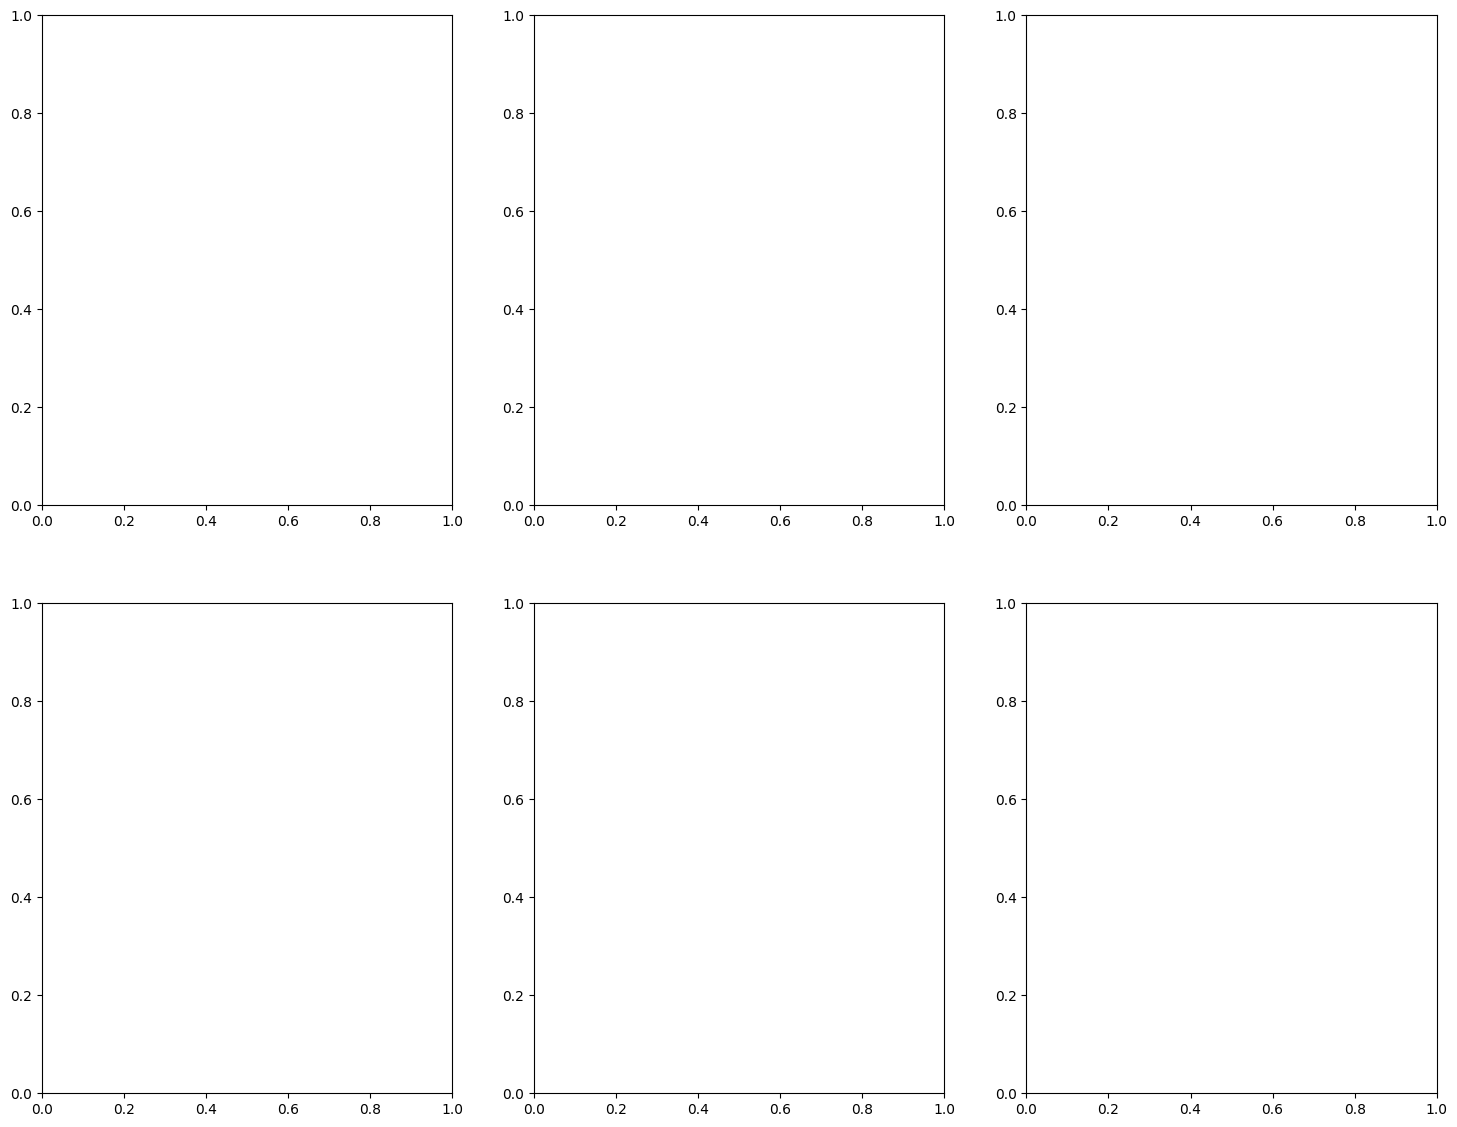

In [7]:
# Cell 5 — Full-mosaic inference with TTA + overlapping tiles + tuned threshold
import gc

for var in ['model', 'model2', 'train_ds', 'train_ds2', 'val_ds', 'val_ds2',
            'train_loader', 'train_loader2', 'val_loader', 'val_loader2',
            'pseudo_candidates', 'pseudo_candidates2', 'optimizer', 'optimizer2',
            'scaler', 'scaler2', 'scheduler', 'scheduler2']:
    if var in dir():
        try: exec(f'del {var}')
        except: pass
gc.collect()
gc.collect()
torch.cuda.empty_cache()
print(f'GPU memory freed: {torch.cuda.memory_allocated()/1e6:.0f} MB used')

best_path = os.path.join(OUT_DIR, 'best_binary_unet_v5.pth')

model_inf = smp.Unet(encoder_name='resnet34', encoder_weights=None,
                      in_channels=3, classes=1).to(DEVICE)
model_inf.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=True))
model_inf.eval()

TILE = 512
STEP = 384
DS = 8
VIS_MAX = 2000
THRESHOLD = 0.4

def contrast_stretch_b4(rgb, valid_mask):
    out = np.zeros_like(rgb, dtype=np.uint8)
    for c in range(3):
        ch = rgb[:,:,c].astype(np.float64)
        vpx = ch[valid_mask]
        if vpx.size < 100: continue
        lo, hi = np.percentile(vpx, [2, 98])
        if hi - lo < 5: continue
        s = np.clip((ch - lo) / (hi - lo) * 255, 0, 255).astype(np.uint8)
        s[~valid_mask] = 0
        out[:,:,c] = s
    return out

def tta_predict(model, img_t):
    preds = []
    for k in range(4):
        x = torch.rot90(img_t, k, dims=[2, 3])
        with torch.amp.autocast('cuda'):
            logit = model(x)
            prob = torch.sigmoid(logit)
        prob = torch.rot90(prob, -k, dims=[2, 3])
        preds.append(prob)
    return torch.stack(preds).mean(dim=0)

def predict_mosaic(fpath, model, tile=TILE, step=STEP, ds=DS):
    with rasterio.open(fpath) as src:
        W, H = src.width, src.height

    out_h, out_w = H // ds, W // ds
    tile_ds = tile // ds
    pred_sum = np.zeros((out_h, out_w), dtype=np.float32)
    count_map = np.zeros((out_h, out_w), dtype=np.float32)
    print(f'  Image: {W}x{H} -> output: {out_w}x{out_h} ({pred_sum.nbytes/1e6:.0f} MB)')

    total = ((H - tile) // step + 1) * ((W - tile) // step + 1)
    done = 0

    with rasterio.open(fpath) as src:
        for row in range(0, H - tile + 1, step):
            for col in range(0, W - tile + 1, step):
                data = src.read([1, 2, 3, 4],
                                window=Window(col, row, tile, tile))
                valid = data[3] == 255
                if valid.sum() < tile * tile * 0.3:
                    done += 1
                    continue

                rgb = data[:3].astype(np.float32) / 255.0
                img_t = torch.from_numpy(rgb).float()
                img_t = (img_t - IMG_MEAN) / IMG_STD

                with torch.no_grad():
                    prob = tta_predict(model, img_t.unsqueeze(0).to(DEVICE))
                    prob = prob.cpu().numpy()[0, 0].astype(np.float32)

                prob[~valid] = 0
                valid_f = valid.astype(np.float32)

                prob_ds = prob.reshape(tile_ds, ds, tile_ds, ds).mean(axis=(1, 3))
                valid_ds = valid_f.reshape(tile_ds, ds, tile_ds, ds).mean(axis=(1, 3))

                r0 = row // ds
                c0 = col // ds
                r1 = min(r0 + tile_ds, out_h)
                c1 = min(c0 + tile_ds, out_w)

                pred_sum[r0:r1, c0:c1] += prob_ds[:r1-r0, :c1-c0]
                count_map[r0:r1, c0:c1] += valid_ds[:r1-r0, :c1-c0]
                done += 1

                del data, rgb, img_t, prob, valid, valid_f, prob_ds, valid_ds

            if done % 500 == 0:
                print(f'    {done}/{total} tiles ...')

    pred_avg = np.where(count_map > 0, pred_sum / count_map, 0)
    binary = (pred_avg > THRESHOLD).astype(np.uint8)
    canal_pct = binary.sum() / max(1, binary.size) * 100
    del pred_sum, count_map

    vis_scale = max(1, max(out_h, out_w) // VIS_MAX)
    vh, vw = out_h // vis_scale, out_w // vis_scale
    print(f'  Vis scale: {vis_scale}x -> {vw}x{vh}')

    binary_vis = cv2.resize(binary, (vw, vh), interpolation=cv2.INTER_NEAREST)
    prob_vis = cv2.resize(pred_avg, (vw, vh), interpolation=cv2.INTER_LINEAR)
    del binary, pred_avg

    with rasterio.open(fpath) as src:
        thumb = src.read([1, 2, 3, 4], out_shape=(4, vh, vw))
    rgb_vis = thumb[:3].transpose(1, 2, 0)
    valid_vis = thumb[3] == 255
    del thumb

    rgb_vis = contrast_stretch_b4(rgb_vis, valid_vis)

    print(f'  Canal pixels: {canal_pct:.2f}% (threshold={THRESHOLD})')
    return binary_vis, prob_vis, rgb_vis

test_files = {
    'ATTANUR_2 (train)': TRAIN_FILES['ATTANUR_2'][0],
    'ATTANUR_1 (val)':   VAL_FILES['ATTANUR_1'][0],
}

fig, axes = plt.subplots(len(test_files), 3, figsize=(18, 7 * len(test_files)))
if len(test_files) == 1:
    axes = axes[np.newaxis, :]

for idx, (label, fpath) in enumerate(test_files.items()):
    print(f'\nProcessing {label} ...')
    t0 = time.time()
    binary_vis, prob_vis, rgb_vis = predict_mosaic(fpath, model_inf)
    dt = time.time() - t0
    print(f'  Done in {dt:.0f}s')

    overlay = rgb_vis.copy()
    overlay[binary_vis == 1] = (overlay[binary_vis == 1] * 0.4 + np.array([0, 255, 255]) * 0.6).astype(np.uint8)

    axes[idx, 0].imshow(rgb_vis)
    axes[idx, 0].set_title(f'{label} — RGB', fontsize=11)
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(prob_vis, cmap='hot', vmin=0, vmax=1)
    axes[idx, 1].set_title(f'{label} — Probability map', fontsize=11)
    axes[idx, 1].axis('off')

    axes[idx, 2].imshow(overlay)
    axes[idx, 2].set_title(f'{label} — Canal overlay (cyan)', fontsize=11)
    axes[idx, 2].axis('off')

    del binary_vis, prob_vis, rgb_vis, overlay
    gc.collect()

iou_label = f'{best_iou:.3f}' if 'best_iou' in dir() else 'v5'
plt.suptitle(f'Full-Mosaic Canal Detection (v5, ResNet34, IoU={iou_label}, TTA4, thr={THRESHOLD})', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'full_mosaic_inference_v5.png'), dpi=100, bbox_inches='tight')
plt.show()
print(f'\nSaved to: {os.path.join(OUT_DIR, "full_mosaic_inference_v5.png")}')

In [ ]:
# Cell 6 — Patch-level predictions from orthomosaic
import gc
gc.collect()
torch.cuda.empty_cache()

best_path = os.path.join(OUT_DIR, 'best_binary_unet_v5.pth')

model_vis = smp.Unet(encoder_name='resnet34', encoder_weights=None,
                      in_channels=3, classes=1).to(DEVICE)
model_vis.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=True))
model_vis.eval()

THRESHOLD = 0.4

def contrast_stretch_b4(rgb, valid_mask):
    out = np.zeros_like(rgb, dtype=np.uint8)
    for c in range(3):
        ch = rgb[:,:,c].astype(np.float64)
        vpx = ch[valid_mask]
        if vpx.size < 100: continue
        lo, hi = np.percentile(vpx, [2, 98])
        if hi - lo < 5: continue
        s = np.clip((ch - lo) / (hi - lo) * 255, 0, 255).astype(np.uint8)
        s[~valid_mask] = 0
        out[:,:,c] = s
    return out

ALL_FILES = {**TRAIN_FILES, **VAL_FILES}
N_SHOW = 8
STRIDE = 2048
random.seed(123)

print('Sampling canal-rich patches from orthomosaics ...')
candidates = []

for tag, (fpath, px_m) in ALL_FILES.items():
    with rasterio.open(fpath) as src:
        W, H = src.width, src.height

    with rasterio.open(fpath) as src:
        for row_off in range(0, H - PATCH_SIZE, STRIDE):
            for col_off in range(0, W - PATCH_SIZE, STRIDE):
                data = src.read([1, 2, 3, 4],
                                window=Window(col_off, row_off, PATCH_SIZE, PATCH_SIZE))
                valid = data[3] == 255
                if valid.sum() / valid.size < 0.7:
                    continue

                rgb = data[:3].astype(np.float32) / 255.0
                img_t = torch.from_numpy(rgb).float()
                img_t = (img_t - IMG_MEAN) / IMG_STD
                with torch.no_grad():
                    with torch.amp.autocast('cuda'):
                        logits = model_vis(img_t.unsqueeze(0).to(DEVICE))
                        prob = torch.sigmoid(logits).cpu().numpy()[0, 0]

                prob[~valid] = 0
                canal_frac = (prob > THRESHOLD).sum() / max(1, valid.sum())

                if canal_frac > 0.02:
                    rgb_hwc = data[:3].transpose(1, 2, 0).astype(np.uint8)
                    candidates.append({
                        'tag': tag, 'rgb': rgb_hwc, 'valid': valid,
                        'prob': prob, 'canal_frac': canal_frac
                    })

    print(f'  {tag}: {len(candidates)} canal patches so far')

print(f'\nTotal candidates: {len(candidates)}')

candidates.sort(key=lambda x: x['canal_frac'], reverse=True)
if len(candidates) > N_SHOW:
    step = len(candidates) // N_SHOW
    chosen = [candidates[i * step] for i in range(N_SHOW)]
else:
    chosen = candidates[:N_SHOW]

n = len(chosen)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 9))
if n == 1:
    axes = axes[:, np.newaxis]

fig.suptitle(f'Model v5 Predictions on Orthomosaic Patches (threshold={THRESHOLD})\n'
             'Row 1: RGB  |  Row 2: Prediction overlay (cyan = canal)',
             fontsize=13, y=1.02)

for i, cand in enumerate(chosen):
    rgb_vis = contrast_stretch_b4(cand['rgb'], cand['valid'])
    pred_bin = (cand['prob'] > THRESHOLD).astype(np.uint8)

    overlay = rgb_vis.copy()
    overlay[pred_bin == 1] = (overlay[pred_bin == 1] * 0.4 + np.array([0, 210, 210]) * 0.6).astype(np.uint8)

    axes[0, i].imshow(rgb_vis);    axes[0, i].axis('off')
    axes[1, i].imshow(overlay);    axes[1, i].axis('off')
    axes[0, i].set_title(f'{cand["tag"][:8]}', fontsize=9)
    axes[1, i].set_title(f'canal={cand["canal_frac"]*100:.1f}%', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(os.path.join(OUT_DIR, 'patch_predictions_v5.png'), dpi=140, bbox_inches='tight')
plt.show()
print(f'\nSaved to: {os.path.join(OUT_DIR, "patch_predictions_v5.png")}')

NameError: name 'torch' is not defined